In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("VideoGamesSales.csv")
df1 = df.copy()
df1.shape


(5909, 15)

In [6]:
df1.drop_duplicates(inplace = True)
df1.shape

(5893, 15)

In [7]:
# filling NA values

df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5893 entries, 0 to 5908
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Rank           5893 non-null   int64  
 1   Name           5893 non-null   object 
 2   Platform       5893 non-null   object 
 3   Year           5893 non-null   int64  
 4   Month          5893 non-null   object 
 5   Genre          5893 non-null   object 
 6   Publisher      5881 non-null   object 
 7   Country        5893 non-null   object 
 8   City           5893 non-null   object 
 9   State          5893 non-null   object 
 10  Region         5866 non-null   object 
 11  NA_Sales       5893 non-null   object 
 12  Global_Sales   5893 non-null   float64
 13  NA_Profit      5893 non-null   float64
 14  Global_Profit  5893 non-null   float64
dtypes: float64(3), int64(2), object(10)
memory usage: 736.6+ KB


In [8]:
df1["Publisher"] = df1["Publisher"].ffill()
df1["Region"] = df1["Region"].ffill()

In [9]:
df1[["Publisher" , "Region"]].shape

(5893, 2)

In [10]:
df1["Country"] = df1["Country"].replace("USA" , "United States" )

df3 = df1[df1["Country"]=="United States"] # cheecking how many countries are US
df3.tail(20)
df3.shape

(2785, 15)

In [11]:
# RENAMING COLUMNS
df1 = df1.rename(columns = {"NA_Sales" : "National Sales","Global_Sales" : "Global Sales","NA_Profit":"National Profit" ,"Global_Profit" :"Global Profit"})


# CLEANING DATA

df1["National Sales"] = df1["National Sales"].replace("[$]" , '' , regex = True)

df1["Platform"] = df1["Platform"].str.strip()

df1["Month"] = df1["Month"].replace("October" , "Oct")


In [ ]:
df1["Month"].unique()
df1["Platform"].unique()

In [13]:
df1["National Sales"] = pd.to_numeric(
    df1["National Sales"],
    errors="coerce"
)

In [14]:
# VISUALIATION

national_sales = df1.groupby(["Region","Country"], as_index = False)["National Sales"].sum().sort_values(by = "National Sales" ,ascending = False)
national_sales
# print(df1["National Sales"].dtype)

,Region,Country,National Sales
8,West,United States,1022.63
2,East,United States,842.70
0,Central,United States,707.58
7,West,Australia,687.18
6,South,United States,518.65
4,Other,Australia,28.21
5,South,Australia,16.30
3,North,Australia,11.68
1,East,Australia,1.35


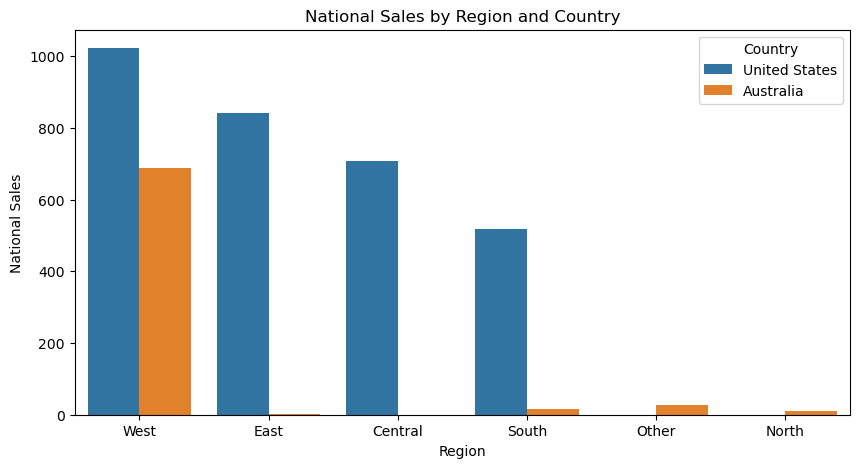

In [15]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=national_sales,
    x="Region",
    y="National Sales",
    hue="Country"
)

plt.title("National Sales by Region and Country")
plt.show()

AS WE CAN SE THAT THE UNITED STATES IS HAVING A HUGE GAP IN NATIONAL SALES IN ALL REGION AS COMPARE TO AUSTRALIA EXCEPT IN THE WEST AUSTRALIA

In [17]:
global_sales = df1.groupby(["Country"], as_index = False) ["Global Sales"].sum().sort_values(by = "Global Sales" ,ascending = False)
global_sales

,Country,Global Sales
1,United States,6315.68
0,Australia,1468.25


<BarContainer object of 9 artists>

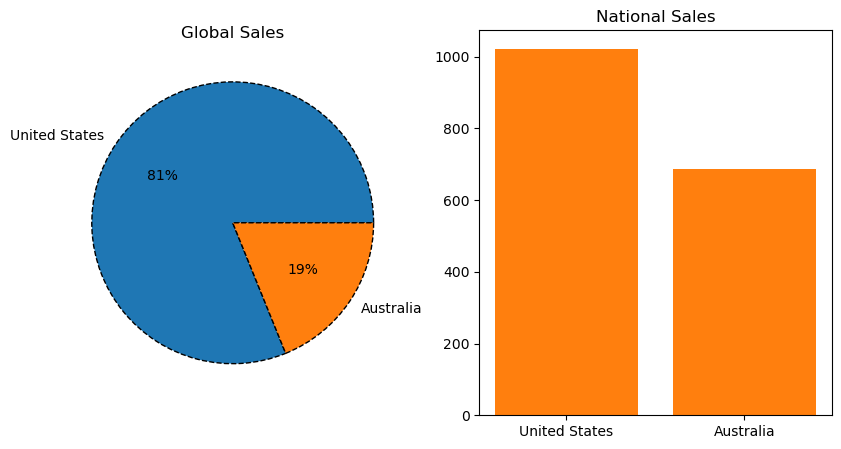

In [18]:
fig , axes = plt.subplots(1,2 , figsize = (10,5))

axes[0].pie(global_sales["Global Sales"],labels=global_sales["Country"],autopct="%.0f%%",
           wedgeprops = {
            'edgecolor' : 'black',
            'linewidth': 1,
            'linestyle': '--' 
        }) 
axes[0].set_title("Global Sales")

axes[1].bar(national_sales["Country"],national_sales["National Sales"])
axes[1].set_title("National Sales")

axes[1].bar(
    national_sales["Country"],
    national_sales["National Sales"]
)


AS WE CAN FROM THE ABOVE CHARTS United States HAS MORE GLOBAL AND NATIONAL SALES AS COMPARE TO Australia

In [19]:
global_profit = df1.groupby(["Country"], as_index = False)["Global Profit"].sum().sort_values(by = "Global Profit" ,ascending = False)
global_profit


,Country,Global Profit
1,United States,1894.704
0,Australia,440.475


In [20]:
national_profitt = df1.groupby(["Country"], as_index = False) ["National Profit"].sum().sort_values(by = "National Profit" ,ascending = False)
national_profitt

,Country,National Profit
1,United States,927.468
0,Australia,223.416


Text(0.5, 0, 'country')

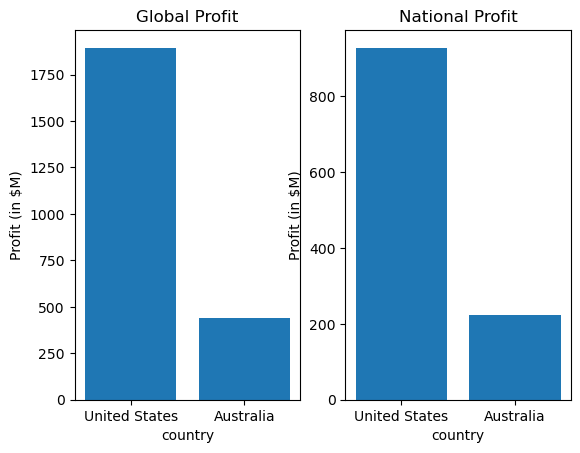

In [21]:
fig , ax = plt.subplots(1,2)

ax[0].bar(global_profit["Country"],global_profit["Global Profit"])
ax[0].set_title("Global Profit")
ax[0].set_ylabel("Profit (in $M)")
ax[0].set_xlabel("country")


ax[1].bar(national_profitt["Country"], national_profitt["National Profit"])
ax[1].set_title("National Profit")
ax[1].set_ylabel("Profit (in $M)")
ax[1].set_xlabel("country")



In [ ]:
 # COMPARISON OF SALES OVER YEARS
yearly_sales = df1.groupby("Year", as_index=False)[["National Sales", "Global Sales"]].sum()
yearly_sales

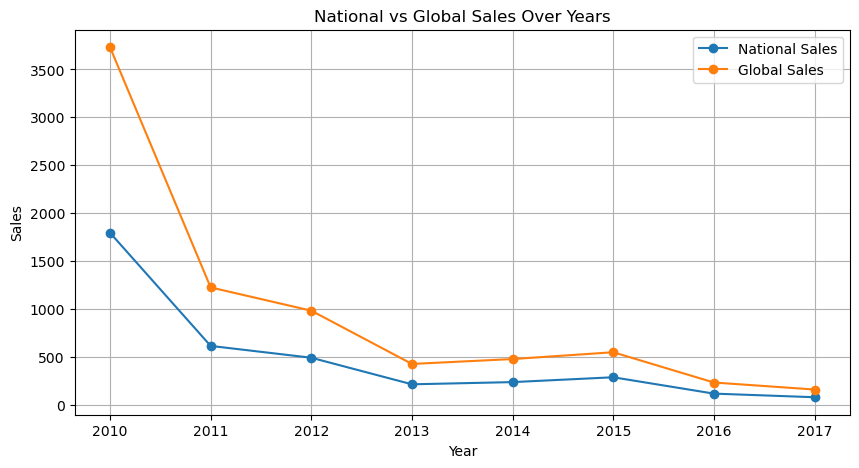

In [23]:
plt.figure(figsize=(10, 5))

plt.plot(yearly_sales["Year"], yearly_sales["National Sales"], marker="o", label="National Sales")
plt.plot(yearly_sales["Year"], yearly_sales["Global Sales"], marker="o", label="Global Sales")

plt.title("National vs Global Sales Over Years")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

FROM THE ABOVE GRAPH WE CAN SEE A STEEP DECLINE IN THE SALES RESPECTIVELY TO YEARS IN BOTH THE COUNTRIES

In [ ]:
yearly_profit = df1.groupby("Year", as_index=False)[["National Profit", "Global Profit"]].sum()
yearly_profit

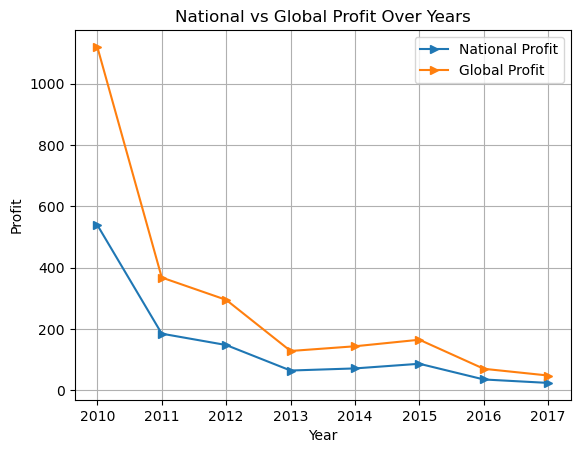

In [25]:

plt.plot(yearly_profit["Year"], yearly_profit["National Profit"], marker=">", label="National Profit")
plt.plot(yearly_profit["Year"], yearly_profit["Global Profit"], marker=">", label="Global Profit")


plt.title("National vs Global Profit Over Years")
plt.xlabel("Year")
plt.ylabel("Profit")
plt.legend()
plt.grid(True)

plt.show()

SINCE THE SALES DECLINE THE PROFIT FOR BOTH THE COUNTRIES ALSO DECLINED WITH THE YEARS